In [86]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print("Gpu enabled: ", torch.cuda.is_available())

Gpu enabled:  True


In [87]:
weight = 50
bias = 0.5

start = 0
stop = 1
step = 0.01

X = torch.arange(start,stop,step).unsqueeze(1)
y = weight * X + bias


X[:5], y[:5]


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.5000],
         [1.0000],
         [1.5000],
         [2.0000],
         [2.5000]]))

In [88]:
split_ratio = int(len(X) * 0.8)

x_train, y_train = X[:split_ratio], y[:split_ratio]
x_test, y_test = X[split_ratio:], y[split_ratio:]


len(x_train), len(y_train), len(x_test), len(y_test)

(80, 80, 20, 20)

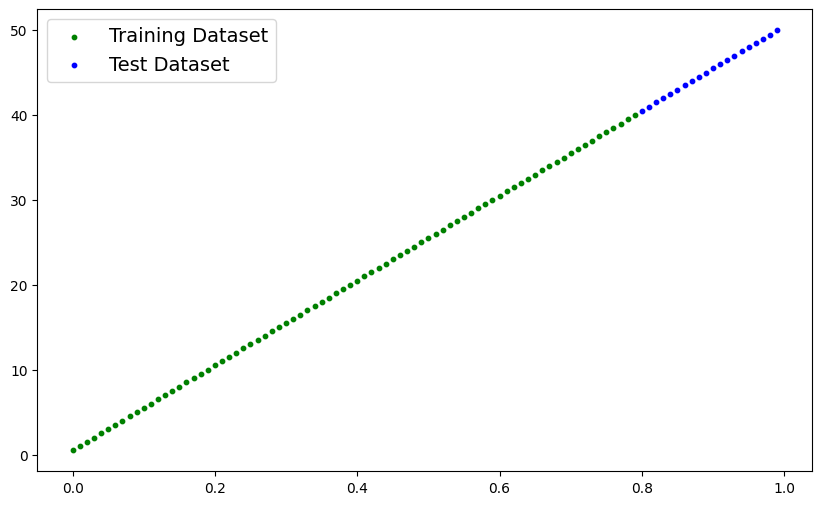

In [89]:
def render_graph(predictions=None):
    plt.figure(figsize=(10,6))
    
    plt.scatter(x_train, y_train, s=10,c="g",label="Training Dataset")
    plt.scatter(x_test, y_test, s=10,c="b",label="Test Dataset")
    
    if predictions is not None:
        plt.scatter(x_test, predictions, s=10,c="r",label="Predictions")
        
    plt.legend(prop={"size":14})
    plt.show()

    
render_graph()

In [90]:
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))
    
    def forward(self, x:torch.Tensor):
        return self.weights * x + self.bias
        
    

In [91]:
torch.manual_seed(42)

model = RegressionModel()
print(model.state_dict())
print(list(model.parameters()))

OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})
[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


tensor([[0.3982],
        [0.4015],
        [0.4049],
        [0.4083],
        [0.4116]])
Number of testing samples: 20
Number of predictions made: 20


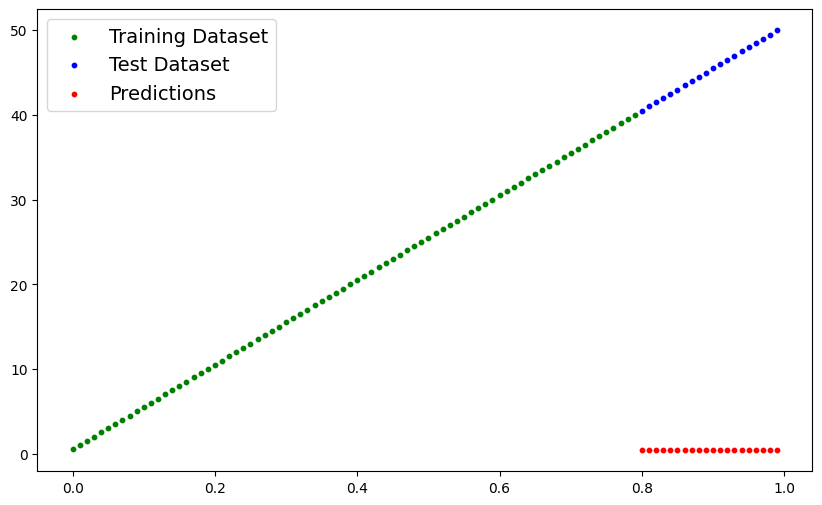

In [92]:
with torch.inference_mode(): 
    y_pred = model(x_test)
    print(y_pred[:5])
print(f"Number of testing samples: {len(x_test)}") 
print(f"Number of predictions made: {len(y_pred)}")
render_graph(predictions=y_pred)

In [93]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.1)

In [94]:
torch.manual_seed(42)

epochs = 5000

for epoch in range(epochs):
    model.train()
    
    model_predictions = model(x_train)
    loss = loss_fn(model_predictions, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch number: {epoch+1}, loss: {loss}")
    
    

Epoch number: 1, loss: 19.98819923400879
Epoch number: 2, loss: 19.872594833374023
Epoch number: 3, loss: 19.75699234008789
Epoch number: 4, loss: 19.64139175415039
Epoch number: 5, loss: 19.526508331298828
Epoch number: 6, loss: 19.415842056274414
Epoch number: 7, loss: 19.305179595947266
Epoch number: 8, loss: 19.19451332092285
Epoch number: 9, loss: 19.083847045898438
Epoch number: 10, loss: 18.97376251220703
Epoch number: 11, loss: 18.867929458618164
Epoch number: 12, loss: 18.762096405029297
Epoch number: 13, loss: 18.656265258789062
Epoch number: 14, loss: 18.550432205200195
Epoch number: 15, loss: 18.444828033447266
Epoch number: 16, loss: 18.343721389770508
Epoch number: 17, loss: 18.242616653442383
Epoch number: 18, loss: 18.141510009765625
Epoch number: 19, loss: 18.040403366088867
Epoch number: 20, loss: 17.939298629760742
Epoch number: 21, loss: 17.840194702148438
Epoch number: 22, loss: 17.743709564208984
Epoch number: 23, loss: 17.647226333618164
Epoch number: 24, loss: 1

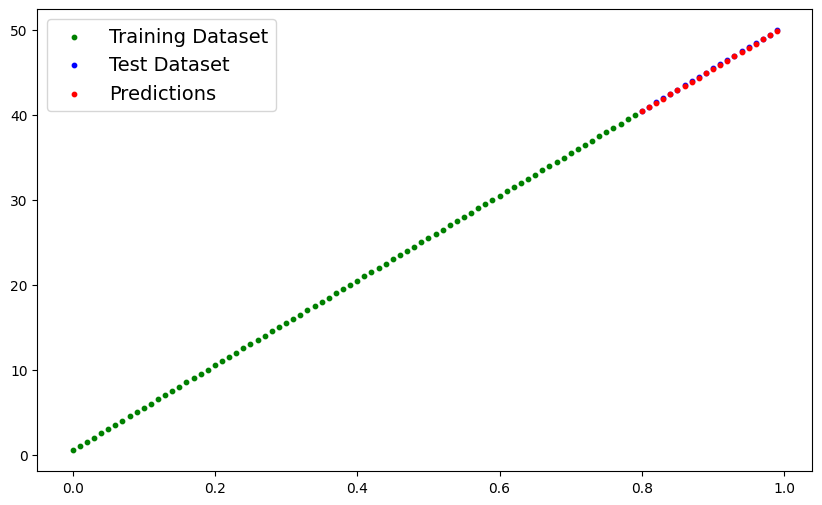

In [95]:
with torch.inference_mode(): 
    modelpred = model(x_test)
    render_graph(modelpred)